문제

- **데이터 준비 및 전처리**
    - "**Red** Wine Quality Dataset"을 로드하고, 주요 특성(와인의 화학적 특성)을 선택하세요.
    - 데이터를 정규화하여 클러스터링을 위한 준비를 하세요.
    - 주요 열은 와인의 화학적 특성('fixed acidity', 'volatile acidity' 등)과 품질 점수(quality)
    
- **K-Means 클러스터링 적용**
    - 클러스터 수를 3으로 설정하고 K-Means 알고리즘을 사용해 클러스터링을 수행하세요.
    - 각 데이터 포인트의 클러스터 레이블을 데이터프레임에 추가하세요.
    
- **클러스터 품질 해석**
    - 각 클러스터의 특성을 분석하고 평균값을 비교하여 클러스터별 차이를 해석하세요.
    - 각 클러스터가 특정 와인 품질(quality) 점수와 관련이 있는지 탐색하세요.
    
- **결과 시각화**
    - PCA를 사용해 데이터를 2차원으로 축소하고 클러스터링 결과를 시각화하세요.

1. **피처 스케일링**: 와인 데이터의 각 특징은 단위와 값의 범위가 극단적으로 다릅니다.
    - 예: `alcohol`은 약 11~14 범위, `proline`은 약 270~1680 범위입니다.
    - K-Means는 유클리드 거리를 기반으로 작동하므로 스케일링을 거치지 않으면 수치가 큰 `proline` 변수에 의해 결과가 지배당합니다.
    반드시 `StandardScaler`를 적용해야 합니다.
2. **K-Means 군집화**: 3개의 와인 품종 그룹으로 분류할 수 있는지 확인하기 위해 *K*=3 군집 모델을 학습합니다.
    
    K=3
    
3. **실루엣 평가**: 군집이 얼마나 뚜렷하게 분류되었는지 실루엣 계수로 평가합니다.
4. **PCA 시각화**: 13차원 데이터를 2차원으로 축소하여 군집화 경계를 산점도로 시각화해 봅니다.

---

- 데이터를 `StandardScaler`로 표준화(평균 0, 분산 1)하여 변수 `X_wine_scaled`에 저장하세요.
- 표준화된 데이터 `X_wine_scaled`를 기반으로 `KMeans` 알고리즘(*K*=3, `random_state=42`, `n_init='auto'`)을 사용해 모델을 선언하고 학습(fit)하세요.
- 학습된 모델의 예측 군집 레이블을 `wine_labels` 변수에 할당하세요.

---

- 앞에서 군집화한 `X_wine_scaled`와 `wine_labels`를 사용해 평균 실루엣 계수(Silhouette Score)를 계산해 변수 `wine_sil_score`에 저장하세요.
- 계산된 점수를 출력하세요.

In [6]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [7]:
from sklearn import set_config

set_config(display="text")

In [5]:
file_path = "winequality-red.csv"

data = pd.read_csv(
    file_path,
    encoding="cp949",
    low_memory=False
)
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [8]:
X = data.drop(columns=["quality"])

In [10]:
scaler = StandardScaler()

In [11]:
X_wine_scaled = scaler.fit_transform(X)

In [13]:
print(X_wine_scaled)

[[-0.52835961  0.96187667 -1.39147228 ...  1.28864292 -0.57920652
  -0.96024611]
 [-0.29854743  1.96744245 -1.39147228 ... -0.7199333   0.1289504
  -0.58477711]
 [-0.29854743  1.29706527 -1.18607043 ... -0.33117661 -0.04808883
  -0.58477711]
 ...
 [-1.1603431  -0.09955388 -0.72391627 ...  0.70550789  0.54204194
   0.54162988]
 [-1.39015528  0.65462046 -0.77526673 ...  1.6773996   0.30598963
  -0.20930812]
 [-1.33270223 -1.21684919  1.02199944 ...  0.51112954  0.01092425
   0.54162988]]


In [15]:
kmeans = KMeans(
    n_clusters=3,
    n_init="auto",
    random_state=42
)

kmeans.fit(X_wine_scaled)

KMeans(n_clusters=3, random_state=42)

In [16]:
wine_labels = kmeans.predict(X_wine_scaled)

In [17]:
data["Cluster"] = wine_labels

In [18]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [19]:
data.groupby("Cluster").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Cluster,,,,,,,,,,,,
0,7.189889,0.609342,0.123047,2.214058,0.078553,13.507618,34.894737,0.995896,3.405762,0.609224,10.494044,5.552632
1,10.067131,0.405080,0.469761,2.582570,0.100460,10.888446,30.627490,0.997574,3.195040,0.752131,10.724037,5.960159
2,8.155467,0.535173,0.289680,3.105467,0.087235,27.108000,89.954667,0.997276,3.284267,0.626533,9.883156,5.362667


In [20]:
data.groupby("Cluster")["quality"].mean()

Cluster
0    5.552632
1    5.960159
2    5.362667
Name: quality, dtype: float64

In [25]:
wine_sil_score = silhouette_score(
    X_wine_scaled,
    wine_labels
)

print("실루엣 점수 : ", wine_sil_score)

실루엣 점수 :  0.1892040681108649


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_wine_scaled)

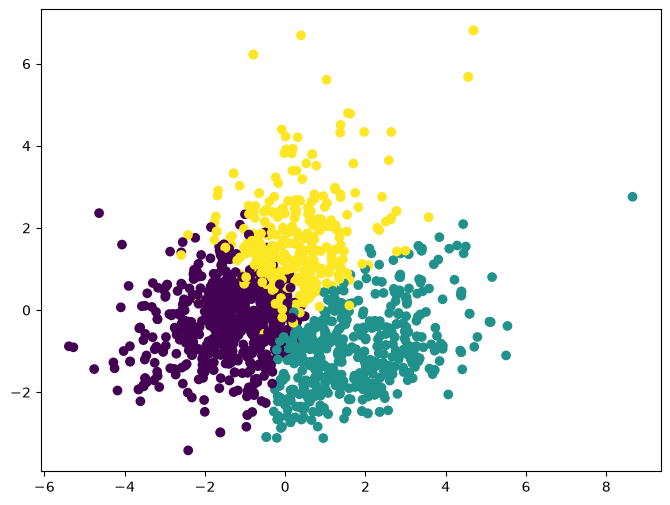

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=wine_labels,
    cmap="viridis"
)